In [1]:
import xgboost as xgb

from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd

import os

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import site_archive_nci

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import shap

In [3]:
# Currently only includes GHI, need solar elevation too!!!
himawari = petdata.archive.Himawari(
    [
    'surface_global_irradiance',
    'solar_elevation'
    ]
)

variables_of_interest = [
    'huss',
    'hus850',
    'hus700',
    'hus500',
    'psl',
    'tas',
    'ta850',
    'ta700',
    'ta500',
    # 'rsds',
]
frequency = '1hr'
domain_id = 'AUST-04'
barra = petdata.archive.BARRA_V2(
    variables_of_interest,
    frequency=frequency,
    domain_id=domain_id
)

In [4]:
satpipe = petpipe.Pipeline(
    himawari,
    petdata.transform.region.Select(latitude=-33.84,longitude=151.22, method='nearest'),
    iterator=petpipe.iterators.DateRange('20240101T00', '20240201T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

barpipe = petpipe.Pipeline(
    barra,
    petdata.transform.region.Select(latitude=-33.84,longitude=151.22, method='nearest'),
    petdata.transform.region.ISelect(height=0),
    iterator=petpipe.iterators.DateRange('20240101T00', '20240201T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

ds_him = satpipe['2024-01']
ds_bar = barpipe['2024-01']

/scratch/nf33/cd3022/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:326: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  full_ds = xr.open_mfdataset(
/scratch/nf33/cd3022/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:209: IndexWarning: Unable to subset on time dimension, returning all timesteps for validation. For request: 2024-01-01T00:00 -> 2024-02-01T00:00 @ 0 days 00:10:00
  warnings.warn(
/scratch/nf33/cd3022/PyEarthTools/packages/data/src/pyearthtools/data/operations/index_routines.py:326: FutureWarning: In a future version of xarray the default value for compat will change from com

In [6]:
dfs = []

# make DFs for pressure level vars
for p in ds_bar.pressure.values:
    tmp = ds_bar.sel(pressure=p).to_dataframe()
    tmp = tmp.rename(columns={'hus': f'hus{int(p)}'})
    tmp = tmp.rename(columns={'ta': f'ta{int(p)}'})
    dfs.append(tmp[['hus' + str(int(p))]])
    dfs.append(tmp[['ta' + str(int(p))]])

# Add surface level vars
base = ds_bar[['huss', 'psl', 'tas']].to_dataframe()

df_bar = base.join(dfs)
df_bar = df_bar.drop(columns=['latitude', 'longitude', 'crs', 'height'], errors='ignore')

In [7]:
df_him = ds_him[['surface_global_irradiance', 'solar_elevation']].to_dataframe()
# df_him = ds_him[['surface_global_irradiance']].to_dataframe()
df_him = df_him.drop(columns=['latitude', 'longitude'], errors='ignore')

data = df_bar.join(df_him, how='inner')

for n in range(1, 11):
    data[f'surface_global_irradiance_t{n}'] = data['surface_global_irradiance'].shift(-n)
data = data.dropna()

In [15]:
data = pd.read_csv('/scratch/er8/cd3022/xgb_datasets/test_data.csv').set_index('time')

In [16]:
X = data.drop(columns=['surface_global_irradiance_t1'])
for n in range(2, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])

# Remove satellite GHI to investigate other variables more closely
X = data.drop(columns=['surface_global_irradiance_t1', 'surface_global_irradiance'])
y = data['surface_global_irradiance_t1']

In [17]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# # Convert back to DataFrame (keeps column names)
# X_scaled = pd.DataFrame(X_scaled, columns=data.columns, index=data.index)

In [19]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = xgb.XGBRegressor(
    random_state=42,
    # device='cuda'
)
model.fit(X_train_scaled, y_train,
        eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
       verbose=False)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Quick evaluation of model performance using correlation and RMSE
correlation = np.corrcoef(y_test, y_pred)[0, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Correlation between predicted and actual values: {correlation:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

Correlation between predicted and actual values: 0.689
Root Mean Squared Error (RMSE): 182.846


In [21]:
model.save_model("/scratch/er8/cd3022/xgb_models/test_model.json")

In [23]:
importance = model.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance)

surface_global_irradiance    0.598958
tas                          0.090394
hus500                       0.066946
hus850                       0.058785
huss                         0.048559
hus700                       0.038814
psl                          0.038545
ta500                        0.023191
ta850                        0.020238
solar_elevation              0.010990
ta700                        0.004579
sigma                        0.000000
level_height                 0.000000
model_level_number           0.000000
dtype: float32


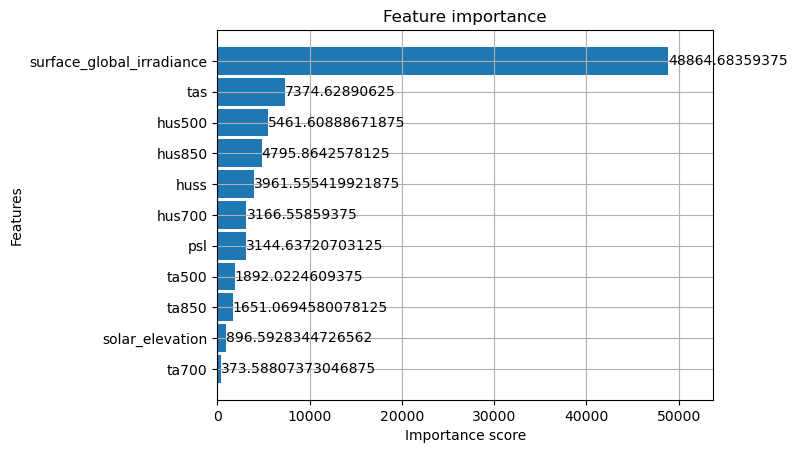

In [24]:
_ = xgb.plot_importance(model, height=0.9, importance_type="gain")

In [25]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train_scaled)

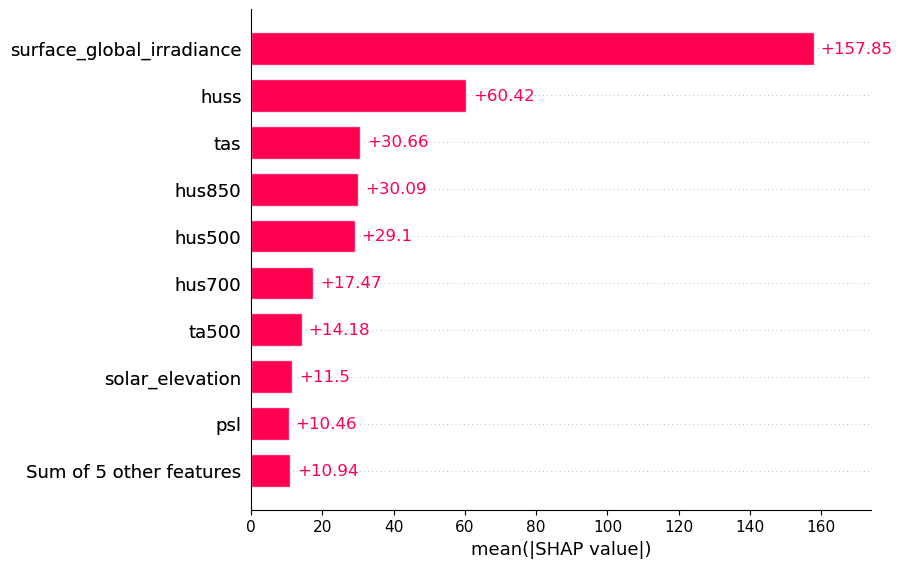

In [26]:
shap.plots.bar(shap_values)

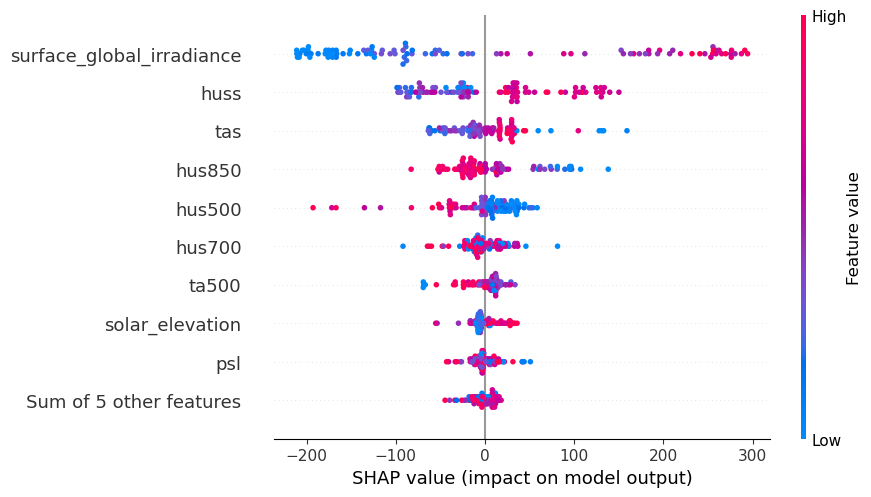

In [27]:
shap.plots.beeswarm(shap_values)